# Phase 2: Exploratory Data Analysis (EDA)

## Introduction
The Exploratory Data Analysis (EDA) phase is a **critical step in the data science pipeline**. Its main purpose is to gain **deep insights into the historical stock performance** of Safaricom Plc (SCOM) and KCB Group Plc (KCB) over the period 2013–2024. Through statistical summaries and visualizations, we aim to **understand patterns, detect anomalies, and assess relationships** between key financial metrics such as price movements, trading volumes, and volatility.

## Objectives
During this phase, we focus on:

- **Analyzing Descriptive Statistics:** Examine central tendencies, variances, and distribution characteristics for price and volume in both datasets.
- **Addressing Data Distribution Issues:** Identify skewness or outliers, particularly in trading volume, and apply transformations (e.g., log transformation) where appropriate.
- **Feature Characterization:** Understand feature behavior to guide feature engineering and prepare the data for predictive modeling.

This EDA lays the foundation for **reliable predictive modeling** by ensuring that the data is well-understood, clean, and appropriately structured for subsequent modeling tasks.

In [1]:
# we import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# we load the safaricom cleaned dataset from the previous phase
scom=pd.read_csv(r"C:\Users\Win\NSE Project\Data\2013 to 2024 CLEANED_cosolidated_SAFARICOM_stocks nse_data.csv")
scom.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume
0,2013-01-02,SCOM,Safaricom Plc,23.5,33.5,5.00,5.15,5.10,5.00,0.10,0.0200,3320600.0
1,2013-01-03,SCOM,Safaricom Plc,23.5,33.5,5.10,5.25,5.15,5.10,0.05,0.0098,7252500.0
2,2013-01-04,SCOM,Safaricom Plc,23.5,33.5,5.15,5.35,5.25,5.15,0.10,0.0194,4125900.0
3,2013-01-07,SCOM,Safaricom Plc,23.5,33.5,5.20,5.45,5.35,5.25,0.10,0.0190,4098600.0
4,2013-01-08,SCOM,Safaricom Plc,23.5,33.5,5.40,5.85,5.60,5.35,0.25,0.0467,10998900.0


In [3]:
#we load the kCB cleaned dataset from our previous phase
kcb=pd.read_csv(r"C:\Users\Win\NSE Project\Data\2013 to 2024 CLEANED_cosolidated_KCB_stocks nse_data.csv")
kcb.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume
0,2013-01-02,KCB,KCB Group Plc,33.75,55.5,30.00,30.50,30.25,29.75,0.10,0.000200,144500.0
1,2013-01-03,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,30.25,0.05,0.000098,790400.0
2,2013-01-04,KCB,KCB Group Plc,33.75,55.5,31.00,31.50,31.00,31.00,0.10,0.000194,5264700.0
3,2013-01-07,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,31.00,0.10,0.000190,2037700.0
4,2013-01-08,KCB,KCB Group Plc,33.75,55.5,30.25,31.25,31.00,31.00,0.25,0.000467,637600.0


In [4]:
scom.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume'],
      dtype='str')

In [5]:
#we see the statistical description of our safaricom data
scom.describe()

,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume
count,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2.980000e+03
mean,21.758121,32.175117,21.719765,22.320285,21.974312,21.971326,0.002987,0.010177,9.924708e+06
std,5.478655,6.643393,9.051604,9.254343,9.149169,9.154322,0.379908,0.013208,1.163546e+07
min,11.500000,21.150000,5.000000,5.150000,5.100000,5.000000,-2.150000,-0.080300,1.028000e+05
25%,23.500000,33.500000,14.850000,15.200000,15.000000,15.000000,-0.150000,0.001900,3.248500e+06
50%,23.500000,33.500000,19.850000,20.250000,19.975000,19.975000,0.000000,0.007100,6.734900e+06
75%,23.500000,33.500000,28.000000,29.000000,28.450000,28.450000,0.150000,0.015300,1.253512e+07
max,34.000000,45.250000,44.000000,45.250000,44.950000,44.950000,2.250000,0.100000,2.084859e+08


In [6]:
#we see the statisical description of our KCB data
kcb.describe()

,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume
count,2980.000000,2980.00000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2980.000000,2.980000e+03
mean,29.722768,51.38104,40.218272,41.246242,40.615386,40.612181,0.002987,0.000102,1.808751e+06
std,7.373361,6.36175,8.817892,8.970546,8.861628,8.864190,0.379908,0.000132,2.429104e+06
min,15.000000,39.00000,15.000000,16.000000,15.750000,15.750000,-2.150000,-0.000803,1.470000e+04
25%,30.000000,50.75000,35.725000,36.800000,36.000000,36.000000,-0.150000,0.000019,3.705500e+05
50%,33.750000,55.50000,39.975000,41.000000,40.250000,40.250000,0.000000,0.000071,1.052550e+06
75%,33.750000,55.50000,45.250000,46.250000,45.500000,45.500000,0.150000,0.000153,2.296975e+06
max,37.000000,55.50000,64.500000,65.500000,65.000000,65.000000,2.250000,0.001000,2.880960e+07


In [7]:
# lets check for volume skewness for safaricom
scom['Volume'].skew()

np.float64(4.949098070806232)

In [8]:
#lets see the volume skewness for our KCB dataset
kcb['Volume'].skew()

np.float64(4.156257737649665)

In [9]:
#in both datasets , the volume colummn is positively skewed, to address this we opt to log transform the column in both datasets
# for the safaricom dataset
scom['Volume_log']=np.log1p(scom['Volume'])
scom.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Volume_log
0,2013-01-02,SCOM,Safaricom Plc,23.5,33.5,5.00,5.15,5.10,5.00,0.10,0.0200,3320600.0,15.015656
1,2013-01-03,SCOM,Safaricom Plc,23.5,33.5,5.10,5.25,5.15,5.10,0.05,0.0098,7252500.0,15.796857
2,2013-01-04,SCOM,Safaricom Plc,23.5,33.5,5.15,5.35,5.25,5.15,0.10,0.0194,4125900.0,15.232795
3,2013-01-07,SCOM,Safaricom Plc,23.5,33.5,5.20,5.45,5.35,5.25,0.10,0.0190,4098600.0,15.226156
4,2013-01-08,SCOM,Safaricom Plc,23.5,33.5,5.40,5.85,5.60,5.35,0.25,0.0467,10998900.0,16.213306


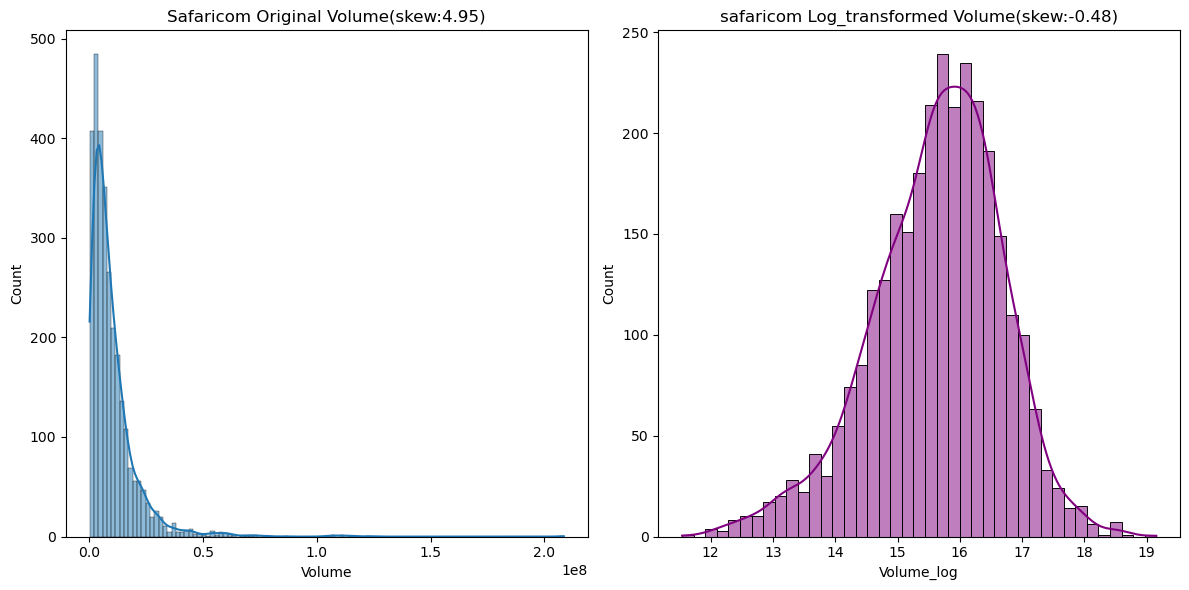

In [10]:
# we now plot the Volume column for safaricom
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(scom['Volume'],kde=True)
plt.title(f"Safaricom Original Volume(skew:{scom['Volume'].skew():.2f})")

plt.subplot(1,2,2)
sns.histplot(scom['Volume_log'],kde=True,color='purple')
plt.title(f"safaricom Log_transformed Volume(skew:{scom['Volume_log'].skew():.2f})")

plt.tight_layout()
plt.show()


### INSIGHTS
- The original volume is highly skewed(positively skewed)(skewness: 4.95). This indicates that on most days, trading volume is relatively low, but there are frequent extreme spikes in activity where volume is exceptionally high.
- After applying a log transformation (np.log1p), the Safaricom volume distribution becomes much more normalized (skewness: -0.19).

In [11]:
# we now move to KCB
kcb['Volume_log']=np.log1p(kcb['Volume'])
kcb.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Volume_log
0,2013-01-02,KCB,KCB Group Plc,33.75,55.5,30.00,30.50,30.25,29.75,0.10,0.000200,144500.0,11.881042
1,2013-01-03,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,30.25,0.05,0.000098,790400.0,13.580296
2,2013-01-04,KCB,KCB Group Plc,33.75,55.5,31.00,31.50,31.00,31.00,0.10,0.000194,5264700.0,15.476535
3,2013-01-07,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,31.00,0.10,0.000190,2037700.0,14.527333
4,2013-01-08,KCB,KCB Group Plc,33.75,55.5,30.25,31.25,31.00,31.00,0.25,0.000467,637600.0,13.365468


In [ ]:
#we now plot the skewness of the KCB Volume Column
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(kcb['Volume'],kde=True)
plt.title(f"KCB Original Volume(skew:{kcb['Volume'].skew():.2f})")

plt.subplot(1,2,2)
sns.histplot(kcb['Volume_log'],kde=True,color='green')
plt.title(f"KCB Log_transformed Volume(skew:{kcb['Volume_log'].skew():.2f})")

plt.tight_layout()
plt.show()

### INSIGHTS
- Similar to Safaricom, the KCB Group trading volume is also highly skewed (skewness: 4.16). The data is clustered toward lower values with a long tail extending toward high-volume trading days.
- The log transformation successfully handled the skewness for KCB as well, resulting in a bell-shaped distribution (skewness: 0.16).


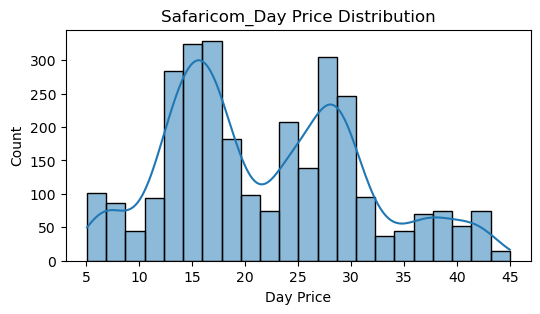

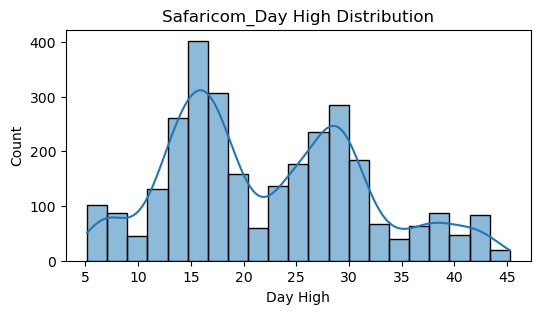

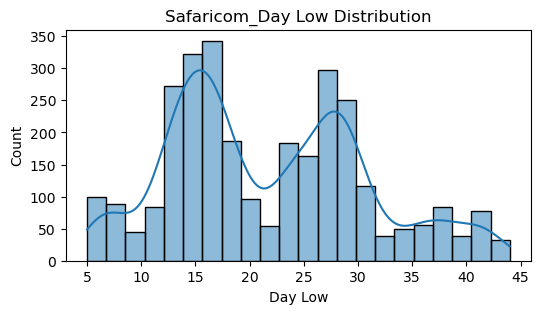

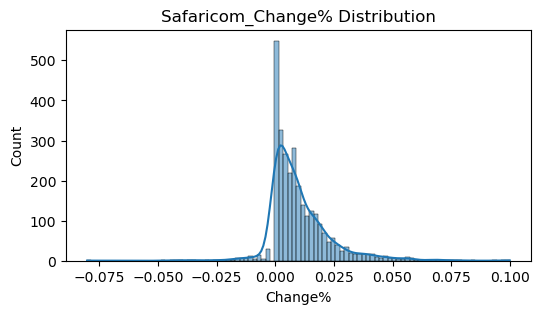

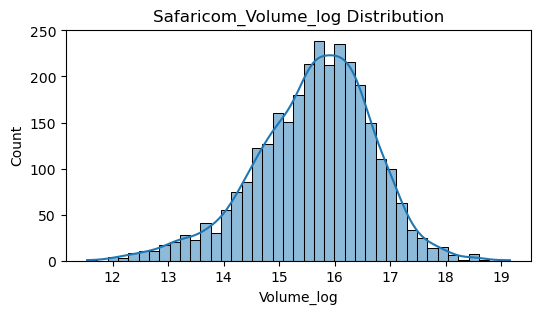

In [13]:
#lets see the distributions of these columns for Safaricom
numeric_cols = ['Day Price', 'Day High', 'Day Low', 'Change%', 'Volume_log']
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(scom[col], kde=True)
    plt.title(f'Safaricom_{col} Distribution')
    plt.show()

## Key Market Insights

### 1. Price Gap Risk (Price / High / Low Plots)

**Insight:**  
The stock forms two dominant price clusters around **~15 KES** and **~28 KES**, with very little activity between **20–25 KES**.

**Implication:**  
This mid-range acts as a **price void**, indicating the market rarely stabilizes within this zone. Movements between the two clusters are typically **rapid and unstable**, reflecting strong historical **support and resistance levels**.

---

### 2. Volatility & Tail Risk (Change % Distribution)

**Insight:**  
A sharp peak around **0% daily change** shows that most trading days experience **minimal price movement**, while the distribution exhibits **fat tails** with outliers beyond **±5%**.

**Implication:**  
Although the market appears calm on most days, the presence of heavy tails indicates **occasional sharp and sudden price movements**, highlighting underlying **tail risk**.

---

### 3. Liquidity Risk (Volume_log Distribution)

**Insight:**  
The near **bell-shaped distribution** of log-transformed trading volume suggests **stable and predictable liquidity**.

**Implication:**  
Most trading activity occurs within a consistent volume range, though deviations in the tails indicate periods of **unusually low liquidity or abnormal trading activity**.

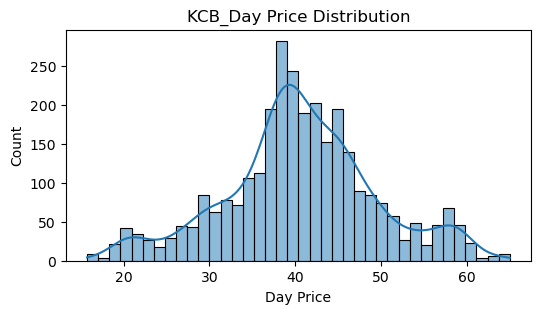

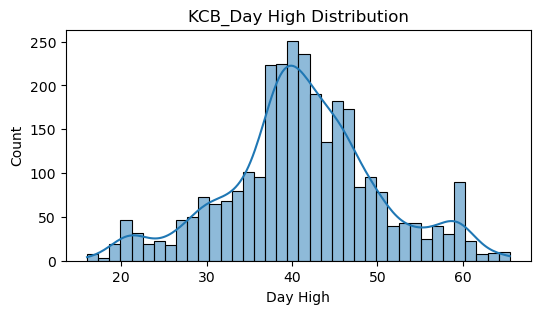

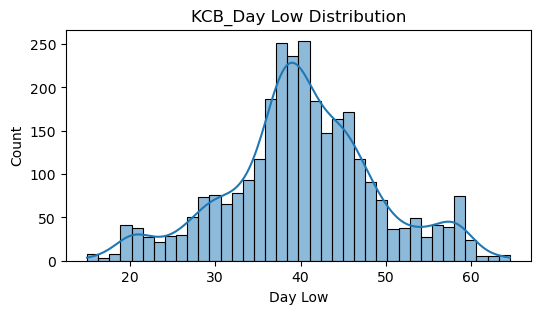

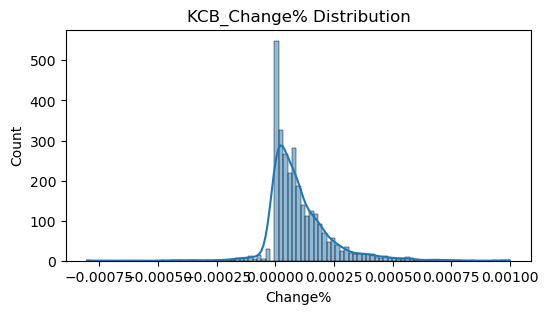

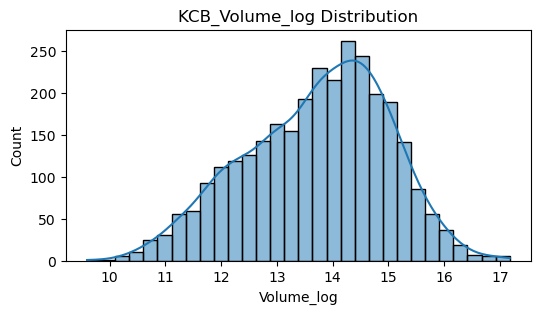

In [14]:
#lets see the distributions of these columns for KCB
numeric_cols = ['Day Price', 'Day High', 'Day Low', 'Change%', 'Volume_log']
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(kcb[col], kde=True)
    plt.title(f'KCB_{col} Distribution')
    plt.show()

## KCB Stock – Risk Insights

### 1. Price Volatility & Multi-Range Behavior (Price / High / Low)

**Insight:**  
KCB prices display a **broad distribution ranging from ~20 to ~65 KES**, with the primary concentration around **~40 KES**.

**Implication:**  
The wider spread and small secondary humps at the extremes indicate **higher price variability** and the tendency for **larger trending swings**, suggesting less stable price clustering compared to Safaricom.

---

### 2. Skewed Return Distribution (Change %)

**Insight:**  
The return distribution shows a **slight positive skew**, with a visible right tail extending toward larger positive changes.

**Implication:**  
While most daily returns cluster around **0%**, the distribution suggests **occasional strong upward movements**. The sharp central peak also indicates **high kurtosis**, meaning most days are quiet but significant moves occur intermittently.

---

### 3. Liquidity Patterns (Volume_log)

**Insight:**  
The log-volume distribution appears **left-skewed**, with a longer tail toward **lower trading volumes**.

**Implication:**  
This suggests **frequent periods of below-average liquidity**, which may increase execution risk during periods of heavy selling or market stress.

Text(0.5, 1.02, 'SAFARICOM-Pairplot of Stock Features')

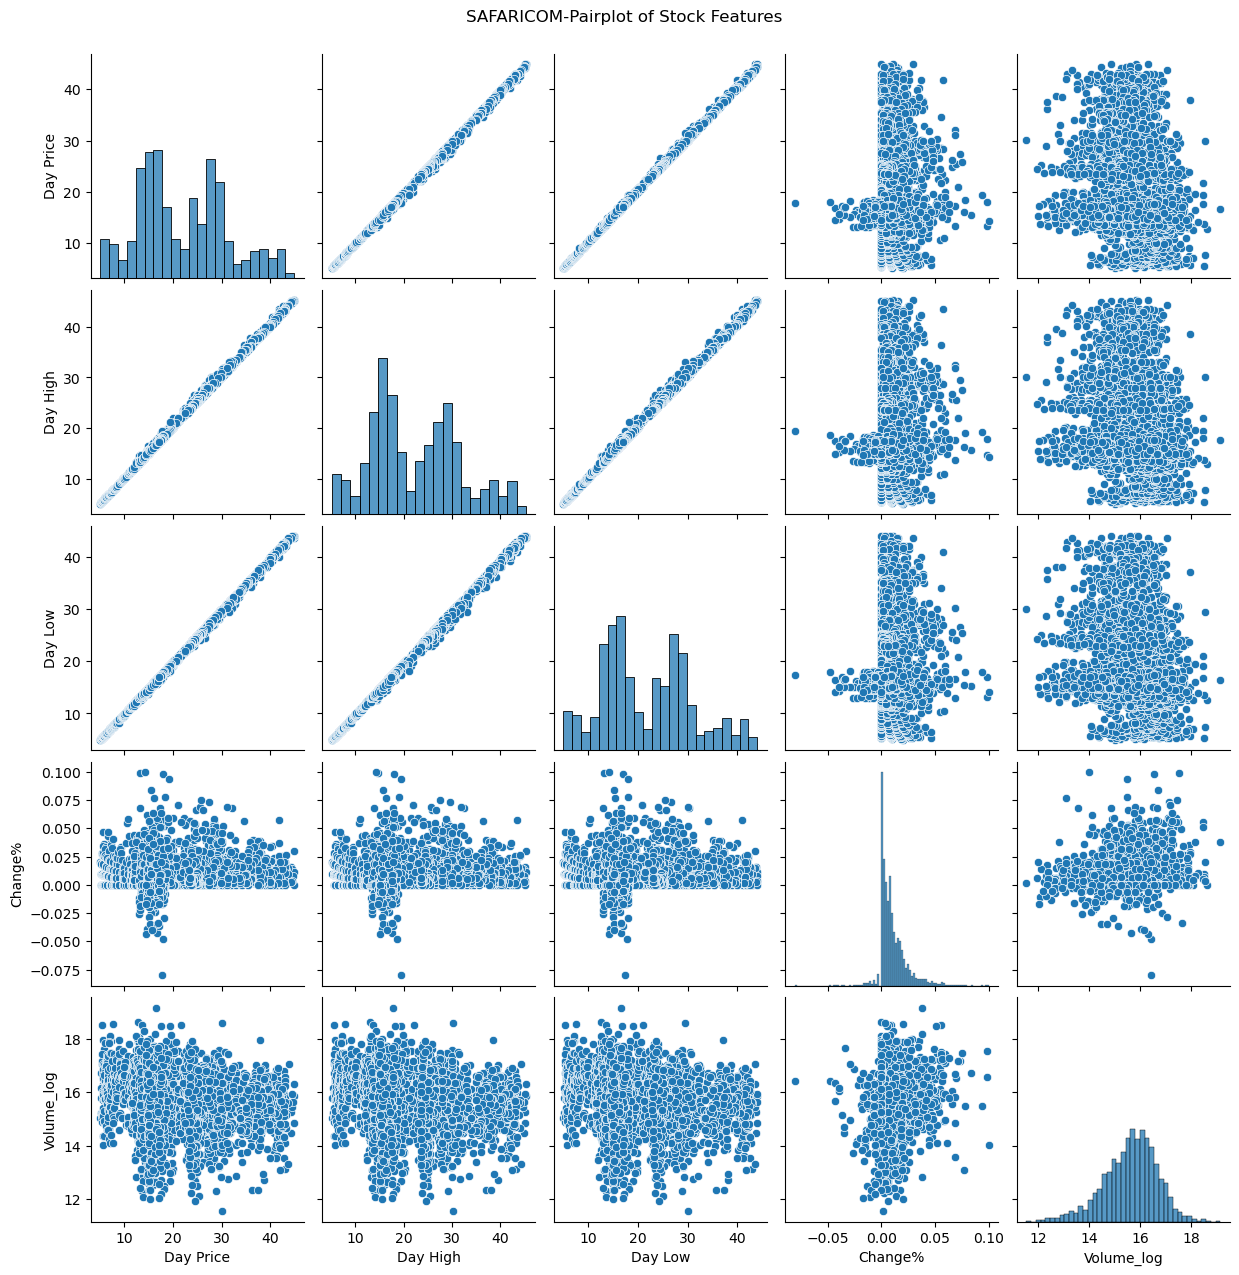

In [15]:
g = sns.pairplot(scom[['Day Price','Day High','Day Low','Change%','Volume_log']])
g.fig.suptitle("SAFARICOM-Pairplot of Stock Features", y=1.02) 

## Feature Interaction Insights (Pairplot)

### 1. Multicollinearity (Price, High, Low)

**Observation:**  
Day Price, Day High, and Day Low form near-perfect linear relationships.

**Implication:**  
These variables move almost identically, indicating **strong multicollinearity**. In modeling or risk tracking, a single price variable can sufficiently represent the others.

---

### 2. Price vs. Volatility (Price vs. Change%)

**Observation:**  
The distribution of **Change%** remains consistent across all price levels.

**Implication:**  
Volatility appears **homoscedastic**, meaning percentage price fluctuations remain relatively stable regardless of the absolute price level.

---

### 3. Liquidity vs. Price (Price vs. Volume_log)

**Observation:**  
The scatter shows **no clear trend** between price and trading volume.

**Implication:**  
Market liquidity remains relatively **consistent across different price levels**, suggesting trading activity does not strongly depend on the stock’s price level.

---

### 4. Volume vs. Returns (Volume_log vs. Change%)

**Observation:**  
The scatter displays a **funnel-like spread**, where larger price swings tend to occur around the average volume levels.

**Implication:**  
Extreme price movements often coincide with **normal-to-high trading volume**, indicating that significant returns are typically supported by active market participation.

Text(0.5, 1.0, 'Correlation Heatmap of SAFARICOM Stock Features')

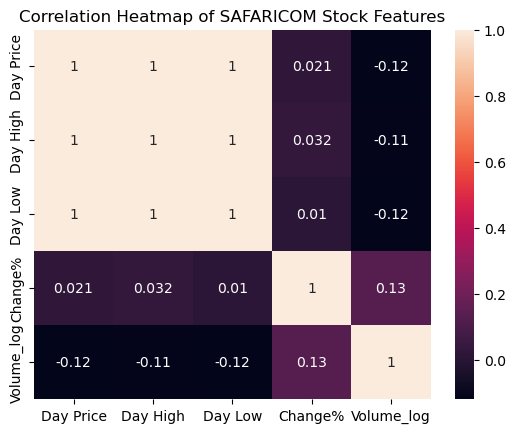

In [16]:
sns.heatmap(scom[['Day Price','Day High','Day Low','Change%','Volume_log']].corr(), annot=True)
plt.title("Correlation Heatmap of SAFARICOM Stock Features")

## safaricom Correlation Matrix Insights

### 1. Extreme Redundancy (Price, High, Low)

**Observation:**  
Day Price, Day High, and Day Low show correlations of **1.00**.

**Implication:**  
These variables are effectively **mathematically redundant**. In modeling or risk estimation (e.g., VaR or regression models), including all three introduces **multicollinearity**, which can lead to **overfitting and numerical instability**.

---

### 2. Independence of Returns (Price vs. Change%)

**Observation:**  
The correlation between **Day Price** and **Change%** is approximately **0.021**.

**Implication:**  
Daily percentage returns are **independent of the absolute price level**, meaning the likelihood of large positive or negative moves does not systematically increase or decrease with price.

---

### 3. Volume–Price Relationship (Price vs. Volume_log)

**Observation:**  
There is a weak **negative correlation (~ -0.12)** between **price** and **log-transformed trading volume**.

**Implication:**  
Trading activity tends to **increase slightly during price declines**, indicating stronger participation during dips and suggesting **responsive market liquidity**.

---

### 4. Momentum Confirmation (Change% vs. Volume_log)

**Observation:**  
The correlation between **Change%** and **Volume_log** is about **0.13**, the strongest non-price relationship in the matrix.

**Implication:**  
Larger daily price movements tend to coincide with **higher trading volume**, implying that significant price changes are often **supported by active market participation** rather than random fluctuations.

Text(0.5, 1.02, 'KCB-Pairplot of Stock Features')

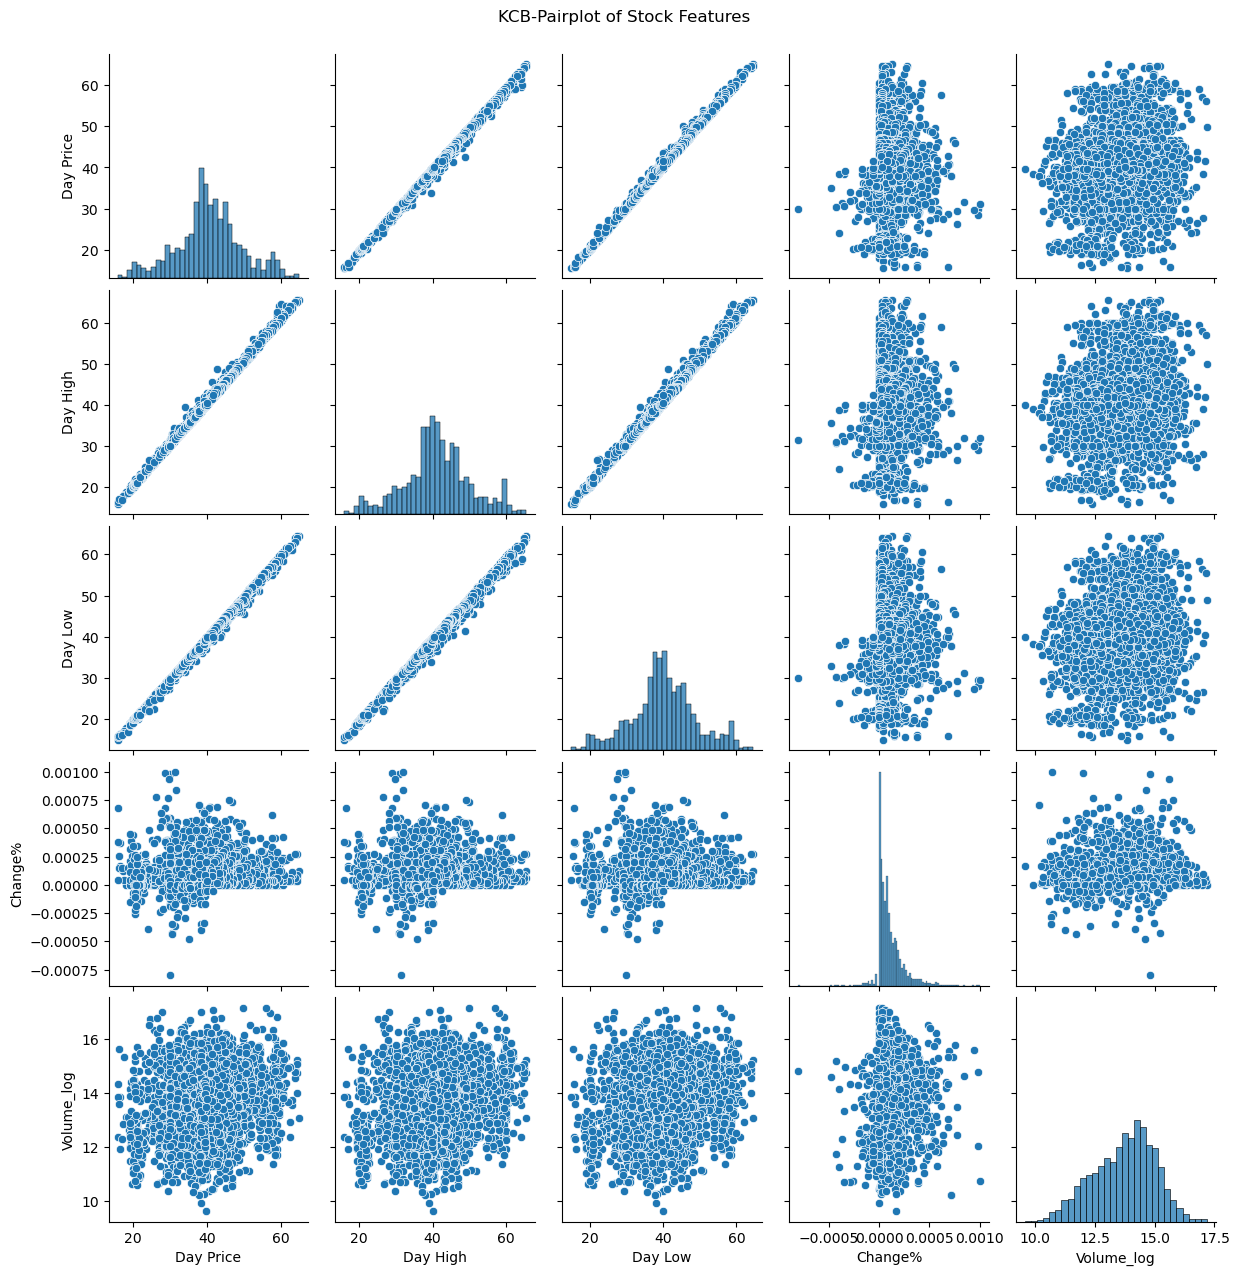

In [17]:
g = sns.pairplot(kcb[['Day Price','Day High','Day Low','Change%','Volume_log']])
g.fig.suptitle("KCB-Pairplot of Stock Features", y=1.02) 

## KCB Pairplot Insights

### 1. Multicollinearity (Price, High, Low)

**Observation:**  
Day Price, Day High, and Day Low exhibit a near-perfect **1:1 linear relationship**.

**Implication:**  
These variables are **highly redundant**, indicating strong multicollinearity. For modeling or risk estimation, a single price metric is sufficient to represent the group.

---

### 2. Asymmetric Volatility (Price vs. Change%)

**Observation:**  
The **Change% vs. Day Price** scatter shows a **bottom-heavy cluster**, particularly around **25–40 KES**.

**Implication:**  
Negative price movements appear more frequent at **mid-to-lower price levels**, suggesting **higher downside volatility** during bearish price regimes.

---

### 3. Liquidity Consistency (Price vs. Volume_log)

**Observation:**  
The **volume distribution remains dense and evenly spread** across the full price range (~20–60+ KES).

**Implication:**  
Trading activity appears **stable across different price levels**, indicating consistent market liquidity.

---

### 4. Outlier Sensitivity (Change% vs. Volume_log)

**Observation:**  
Large positive and negative **Change% outliers** occur even when trading volume is around **average levels**.

**Implication:**  
Significant price movements can occur without unusually high volume, suggesting **greater sensitivity to large trades or thinner order book depth**.

Text(0.5, 1.0, 'Correlation Heatmap of KCB Stock Features')

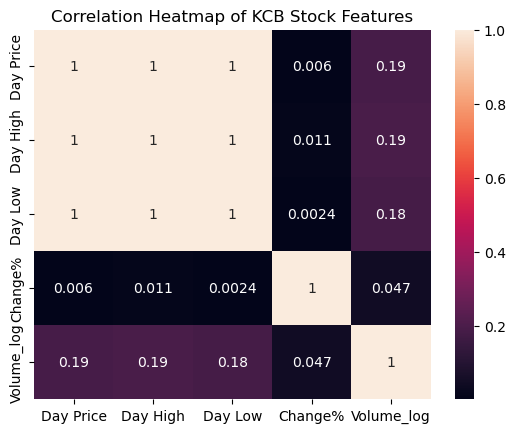

In [18]:
sns.heatmap(kcb[['Day Price','Day High','Day Low','Change%','Volume_log']].corr(), annot=True)
plt.title("Correlation Heatmap of KCB Stock Features")

## KCB Correlation Heatmap Insights

### 1. Redundant Price Variables

**Observation:**  
Day Price, Day High, and Day Low show **perfect correlations (~1.00)**.

**Implication:**  
These variables are **functionally identical** for modeling purposes. Including all of them introduces **multicollinearity**, so a single price variable is sufficient for analysis or predictive modeling.

---

### 2. Price–Volume Relationship

**Observation:**  
Price and **Volume_log** exhibit a **positive correlation (~0.19)**.

**Implication:**  
Trading volume tends to **increase as price rises**, indicating momentum-driven participation. Bullish price movements are often accompanied by stronger market activity.

---

### 3. Independence of Returns

**Observation:**  
The correlation between **Day Price** and **Change%** is approximately **0.006**.

**Implication:**  
Daily returns appear **independent of the price level**, meaning the magnitude or direction of price changes does not systematically depend on whether the stock is trading at higher or lower prices.

---

### 4. Weak Volume–Return Relationship

**Observation:**  
**Volume_log** and **Change%** show a **very weak correlation (~0.047)**.

**Implication:**  
Large price movements are **not strongly tied to trading volume**, suggesting that significant returns can occur even without unusually high market participation.

<Axes: title={'center': 'SAFARICOM Day Price over Time'}, xlabel='DATE'>

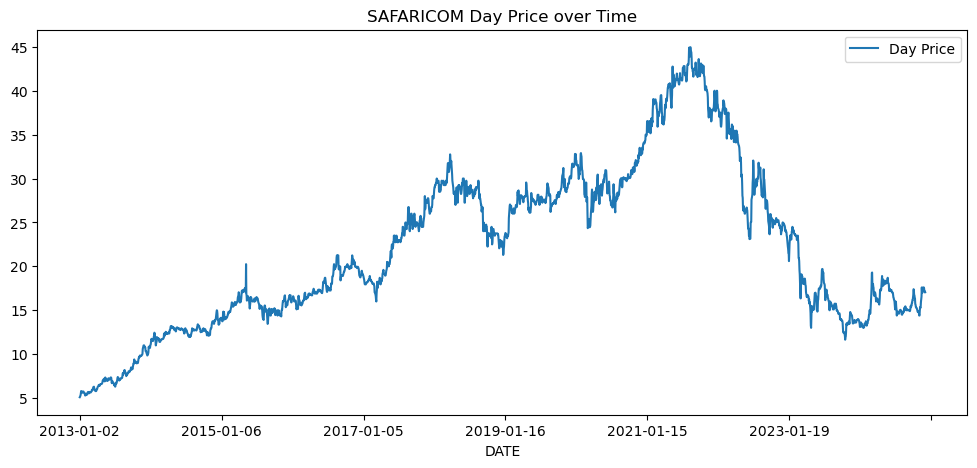

In [19]:
scom.plot(x='DATE', y='Day Price', figsize=(12,5), title='SAFARICOM Day Price over Time')

<Axes: title={'center': 'KCB Day Price over Time'}, xlabel='DATE'>

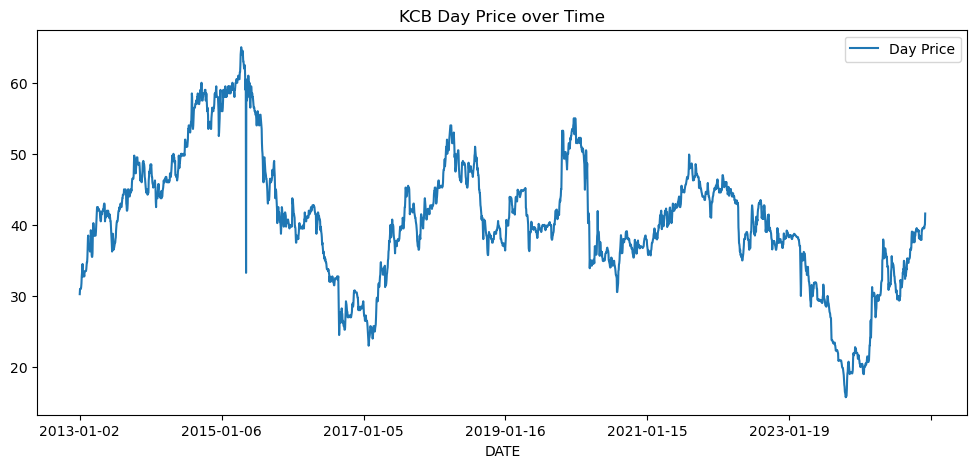

In [20]:
kcb.plot(x='DATE', y='Day Price', figsize=(12,5), title='KCB Day Price over Time')

## Time-Series Insights (Historical Price Behavior)

### 1. Trend Dynamics – Safaricom

**Observation:**  
Safaricom exhibits a long-term **mountain-shaped trend**, rising steadily to a peak around **~45 KES in 2021** followed by a prolonged decline and recent price stabilization.

**Implication:**  
The series shows strong **trend persistence**, where major upward or downward movements tend to extend over long periods before stabilizing.

---

### 2. Cyclical Behavior – KCB

**Observation:**  
KCB displays a more **jagged and cyclical pattern**, frequently oscillating between **~20 KES and ~60 KES** without a persistent long-term directional trend.

**Implication:**  
The price dynamics resemble **mean-reverting behavior**, with repeated swings between lower and upper ranges.

---

### 3. Volatility Shocks

**Observation:**  
Sudden vertical price drops are visible in the series (e.g., around **2015** for KCB).

**Implication:**  
These abrupt movements indicate **gap-like volatility events**, where prices adjust sharply within a short time frame.

---

### 4. Comparative Market Position

**Observation:**  
Safaricom currently trades near the **lower end of its long-term range**, while KCB appears to be in a **recovery phase within its cyclical band**.

**Implication:**  
The two assets display **different structural dynamics**: Safaricom reflecting long-term trend shifts, and KCB showing recurring cyclical movements.

## FEATURE ENGINEERING

### 1. SAFARICOM

In [21]:
scom.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Volume_log'],
      dtype='str')

In [22]:
#we do the rolling means to detect trends
#rolling standard deviations to measure volatility over moving window
#we create crossover features to convert trends into binary features
#we are using the windows 5,12,50,and 200
# we use min_periods to cater for the NaN fro the rolling calculations
windows=[5,12,50,200]
#moving avarages
for w in windows:
    scom[f'MA_{w}']=scom['Day Price'].rolling(window=w,min_periods=1).mean()
    scom[f'STD_{w}']=scom['Day Price'].rolling(window=w,min_periods=1).std()
    #cross over features
scom['MA_5_vs_MA_50']= (scom['MA_5']>scom['MA_50']).astype(int)
scom['MA_12_vs_MA_200']= (scom['MA_12']>scom['MA_200']).astype(int)
# volatility feature
scom['HighVol_5_vs_50']=(scom['STD_5']>scom['STD_50']).astype(int)
scom['Daily_Range'] = scom['Day High'] - scom['Day Low']


In [23]:
scom.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,...,MA_12,STD_12,MA_50,STD_50,MA_200,STD_200,MA_5_vs_MA_50,MA_12_vs_MA_200,HighVol_5_vs_50,Daily_Range
0,2013-01-02,SCOM,Safaricom Plc,23.5,33.5,5.00,5.15,5.10,5.00,0.10,...,5.100000,NaN,5.100000,NaN,5.100000,NaN,0,0,0,0.15
1,2013-01-03,SCOM,Safaricom Plc,23.5,33.5,5.10,5.25,5.15,5.10,0.05,...,5.125000,0.035355,5.125000,0.035355,5.125000,0.035355,0,0,0,0.15
2,2013-01-04,SCOM,Safaricom Plc,23.5,33.5,5.15,5.35,5.25,5.15,0.10,...,5.166667,0.076376,5.166667,0.076376,5.166667,0.076376,0,0,0,0.20
3,2013-01-07,SCOM,Safaricom Plc,23.5,33.5,5.20,5.45,5.35,5.25,0.10,...,5.212500,0.110868,5.212500,0.110868,5.212500,0.110868,0,0,0,0.25
4,2013-01-08,SCOM,Safaricom Plc,23.5,33.5,5.40,5.85,5.60,5.35,0.25,...,5.290000,0.198116,5.290000,0.198116,5.290000,0.198116,0,0,0,0.45


Text(0.5, 1.0, 'SAFARICOM daily stock range distribution')

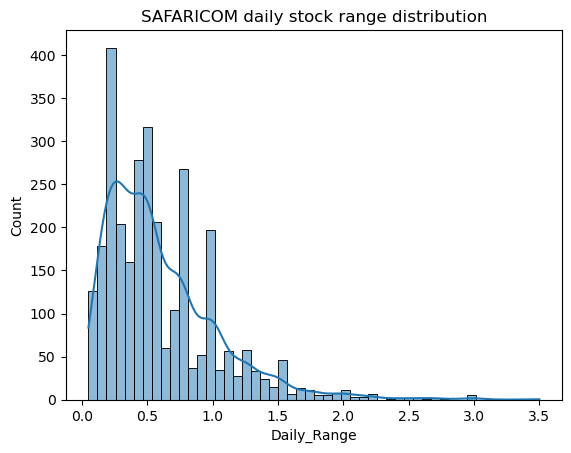

In [24]:
#lets seee the distributin of the stock daily range for safaricom
sns.histplot(scom['Daily_Range'], kde=True)
plt.title("SAFARICOM daily stock range distribution")

## Safaricom Daily Range Insights

### 1. Right-Skewed Volatility
**Observation:** Most daily ranges fall between **0.2–0.8 KES**, with a long tail extending to **~3.5 KES**.  
**Implication:** Intraday volatility is usually low but occasionally experiences **sharp volatility bursts**.

### 2. Typical Daily Movement
**Observation:** The distribution peaks around **~0.25 KES**.  
**Implication:** This represents the **typical intraday fluctuation** for the stock.

### 3. Tail Events
**Observation:** A few observations exceed **2.0 KES** in daily range.  
**Implication:** These represent **rare but significant intraday volatility events**.

### 4. Discrete Price Levels
**Observation:** The histogram shows **visible gaps between bars** rather than a smooth curve.  
**Implication:** Price movements appear to occur in **discrete increments**, suggesting trading activity clusters around specific price levels.

In [28]:
# we check for null values
scom.isnull().sum()

DATE               0
CODE               0
NAME               0
12m Low            0
12m High           0
Day Low            0
Day High           0
Day Price          0
Previous           0
Change             0
Change%            0
Volume             0
Volume_log         0
MA_5               0
STD_5              1
MA_12              0
STD_12             1
MA_50              0
STD_50             1
MA_200             0
STD_200            1
MA_5_vs_MA_50      0
MA_12_vs_MA_200    0
HighVol_5_vs_50    0
Daily_Range        0
dtype: int64

In [43]:
# we opt to drop the first row, that has the nulls
scom=scom.dropna().reset_index(drop=True)

In [44]:
#we check for duplicates
scom.duplicated().sum()

np.int64(0)

In [45]:
scom.head(2)

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,...,MA_12,STD_12,MA_50,STD_50,MA_200,STD_200,MA_5_vs_MA_50,MA_12_vs_MA_200,HighVol_5_vs_50,Daily_Range
0,2013-01-03,SCOM,Safaricom Plc,23.5,33.5,5.10,5.25,5.15,5.10,0.05,...,5.125000,0.035355,5.125000,0.035355,5.125000,0.035355,0,0,0,0.15
1,2013-01-04,SCOM,Safaricom Plc,23.5,33.5,5.15,5.35,5.25,5.15,0.10,...,5.166667,0.076376,5.166667,0.076376,5.166667,0.076376,0,0,0,0.20


In [46]:
scom.isnull().sum()

DATE               0
CODE               0
NAME               0
12m Low            0
12m High           0
Day Low            0
Day High           0
Day Price          0
Previous           0
Change             0
Change%            0
Volume             0
Volume_log         0
MA_5               0
STD_5              0
MA_12              0
STD_12             0
MA_50              0
STD_50             0
MA_200             0
STD_200            0
MA_5_vs_MA_50      0
MA_12_vs_MA_200    0
HighVol_5_vs_50    0
Daily_Range        0
dtype: int64

In [57]:
# Convert DATE column to datetime
scom['DATE'] = pd.to_datetime(scom['DATE'], errors='coerce')


In [58]:
scom.info()

<class 'pandas.DataFrame'>
RangeIndex: 2979 entries, 0 to 2978
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   DATE             2979 non-null   datetime64[us]
 1   CODE             2979 non-null   str           
 2   NAME             2979 non-null   str           
 3   12m Low          2979 non-null   float64       
 4   12m High         2979 non-null   float64       
 5   Day Low          2979 non-null   float64       
 6   Day High         2979 non-null   float64       
 7   Day Price        2979 non-null   float64       
 8   Previous         2979 non-null   float64       
 9   Change           2979 non-null   float64       
 10  Change%          2979 non-null   float64       
 11  Volume           2979 non-null   float64       
 12  Volume_log       2979 non-null   float64       
 13  MA_5             2979 non-null   float64       
 14  STD_5            2979 non-null   float64       
 15

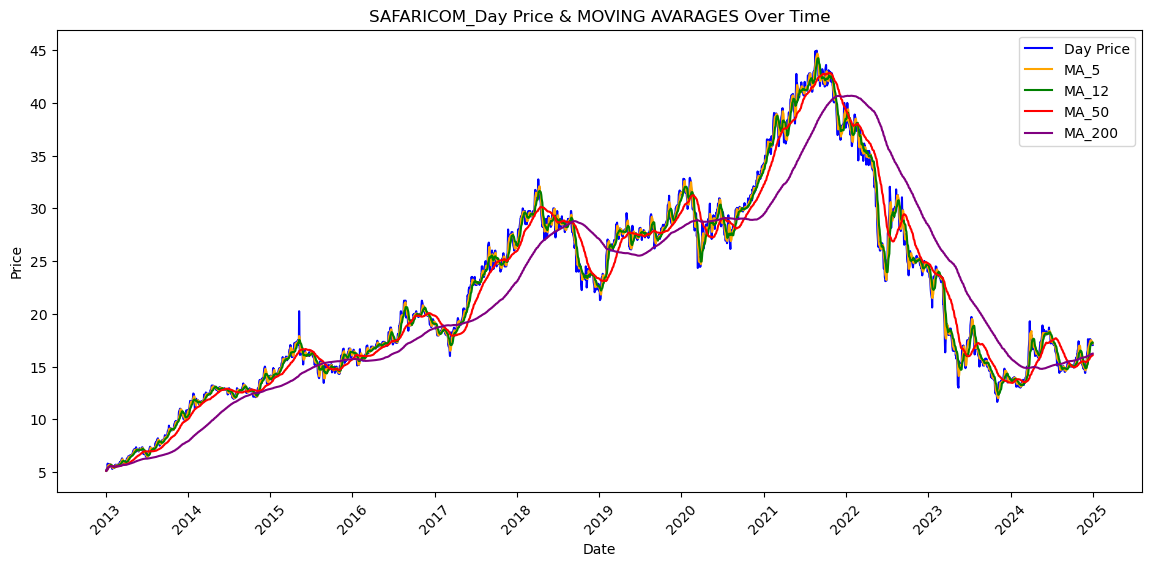

In [62]:
#LETS SEE THE TRENDS OF THE DAILY PRICE VS THE MOVING AVERAGES
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))
plt.plot(scom['DATE'], scom['Day Price'], label='Day Price', color='blue')
plt.plot(scom['DATE'], scom['MA_5'], label='MA_5', color='orange')
plt.plot(scom['DATE'], scom['MA_12'], label='MA_12', color='green')
plt.plot(scom['DATE'], scom['MA_50'], label='MA_50', color='red')
plt.plot(scom['DATE'], scom['MA_200'], label='MA_200', color='purple')
plt.title('SAFARICOM_Day Price & MOVING AVARAGES Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.YearLocator())   # one tick per year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()


## Safaricom Moving Averages Insights

### 1. Structural Bear Market (Death Cross)
**Observation:** Short-term MAs (5, 12, 50) crossed **below the 200-day MA** in late 2021/early 2022.  
**Implication:** Signaled a shift to a **long-term bear market**, with the 200-MA acting as **resistance** since.

### 2. Trend Lag & Sensitivity
**Observation:** MA_5 and MA_12 track price closely, while MA_200 is smooth.  
**Implication:** **Short-term MAs** can produce false signals; **MA_50** serves as a reliable mid-term risk indicator.

### 3. Current Consolidation
**Observation:** MAs are **flattening and converging** in 2024–2025.  
**Implication:** Indicates **reduced volatility** and stalled downward momentum; a break above MA_200 would signal a trend reversal.

### 4. Price Divergence Risk
**Observation:** Large gaps appeared between price and MA_200 during 2022–2023.  
**Implication:** Extreme divergence signals **oversold conditions**, often leading to temporary **mean-reversion bounces**.

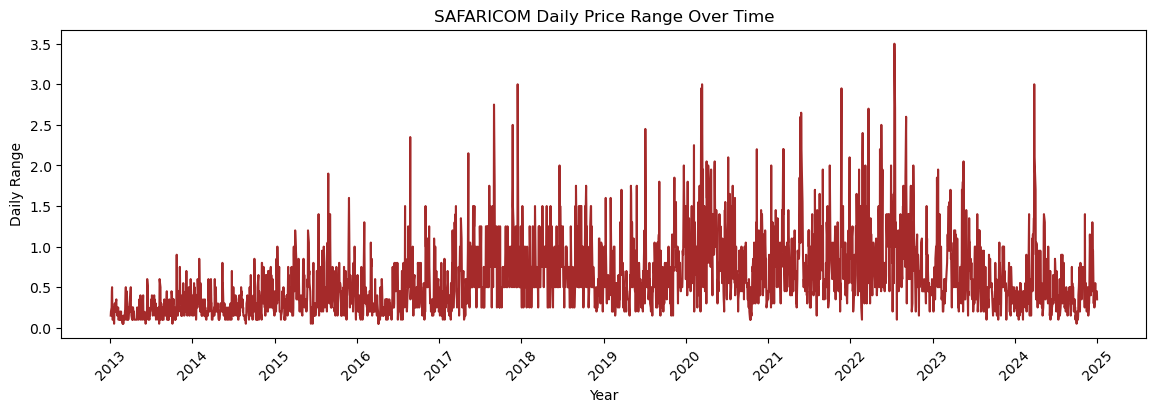

In [66]:
#LETS SEE THE DAILY RANGE OVER TIME
import matplotlib.dates as mdates

plt.figure(figsize=(14,4))
plt.plot(scom['DATE'], scom['Daily_Range'], color='brown')
plt.title('SAFARICOM Daily Price Range Over Time')
plt.xlabel('Year')
plt.ylabel('Daily Range')

# Set major ticks to yearly intervals
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # one tick per year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.show()

## Safaricom Moving Averages Insights

### 1. Death Cross
**Observation:** Short-term MAs (5, 12, 50) fell **below MA_200** in late 2021.  
**Implication:** Marked a **long-term bear market**, with MA_200 now acting as **resistance**.

### 2. Trend Sensitivity
**Observation:** MA_5/MA_12 closely follow price; MA_200 is smooth.  
**Implication:** **Short-term MAs** can produce false signals; **MA_50** is a reliable mid-term indicator.

### 3. Consolidation
**Observation:** MAs are **flattening and converging** (2024–2025).  
**Implication:** **Volatility is decreasing**; a break above MA_200 may indicate a trend reversal.

### 4. Price Divergence
**Observation:** Price was far below MA_200 during 2022–2023.  
**Implication:** Shows **oversold conditions**, often leading to temporary **mean-reversion bounces**.

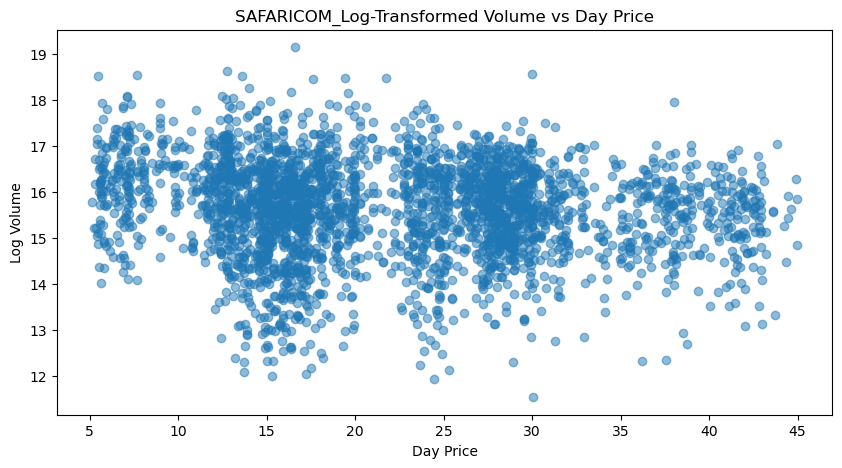

In [67]:
#LETS SEE THE VOLUME VS PRICE RELATIONS
plt.figure(figsize=(10,5))
plt.scatter(scom['Day Price'], scom['Volume_log'], alpha=0.5)
plt.title('SAFARICOM_Log-Transformed Volume vs Day Price')
plt.xlabel('Day Price')
plt.ylabel('Log Volume')
plt.show()

## Safaricom Volume vs. Price Insights

### 1. Liquidity Concentration
**Observation:** Thick vertical clusters appear around **15–18 KES** and **28–30 KES**.  
**Implication:** These are **high-liquidity zones**, allowing large trades with minimal slippage.

### 2. Price–Volume Independence
**Observation:** The scatter is mostly **horizontal**, showing no strong slope.  
**Implication:** Trading activity remains **stable across price levels**, indicating a deep, mature market.

### 3. Low-Volume Tail Risk
**Observation:** Isolated points fall below **~13 log-volume**.  
**Implication:** Rare **illiquid days** increase execution risk, usually due to holidays or market pauses.

### 4. Volume Stability at High Prices
**Observation:** At **40–45 KES**, the vertical spread narrows.  
**Implication:** Higher prices coincide with **more predictable volume**, likely due to institutional buy-and-hold activity.

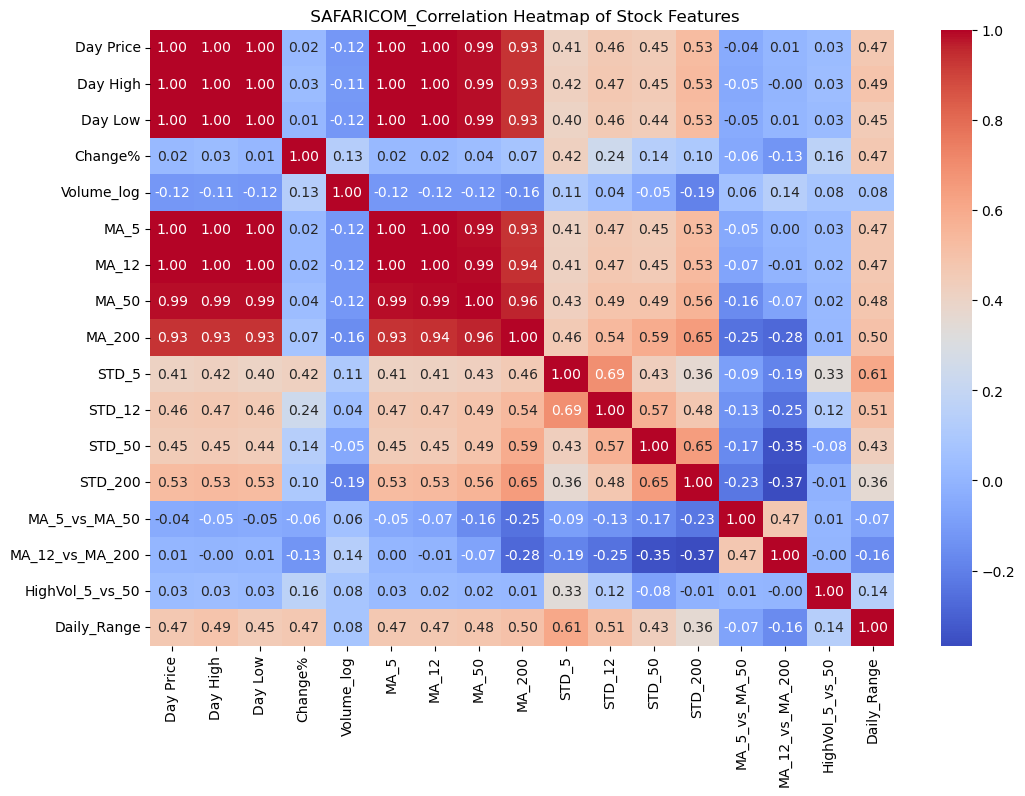

In [52]:
#LETS SEE THE CORELLATION OF OUR ENGINEERED FEATURES
features = ['Day Price','Day High','Day Low','Change%','Volume_log',
            'MA_5','MA_12','MA_50','MA_200','STD_5','STD_12','STD_50','STD_200',
            'MA_5_vs_MA_50','MA_12_vs_MA_200','HighVol_5_vs_50','Daily_Range']

plt.figure(figsize=(12,8))
sns.heatmap(scom[features].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title(" SAFARICOM_Correlation Heatmap of Stock Features")
plt.show()

## Safaricom Expanded Correlation Heatmap Insights

### 1. Extreme Multi-collinearity
**Observation:** Top-left block shows near-perfect correlations (**1.00–0.99**) among Day Price, High, Low, MA_5, and MA_12.  
**Implication:** These features are essentially **redundant**; including all in a model can cause **overfitting**.

### 2. Volatility Persistence
**Observation:** Daily_Range strongly correlates with short-term STDs (**STD_5: 0.61, STD_12: 0.51**).  
**Implication:** High daily ranges indicate **continued volatility** over the next 5–12 days.

### 3. Lagging Indicator Risk (MA_200)
**Observation:** MA_200 has lower correlation with Day Price (**0.93**) compared to other MAs.  
**Implication:** MA_200 **reacts slowly**, making it less reliable for immediate risk exits.

### 4. Change% Independence
**Observation:** Change% shows almost **zero correlation** with price, MAs, or Volume.  
**Implication:** Daily returns behave like a **random walk**, making short-term prediction highly uncertain.

### 5. Volume Divergence
**Observation:** Volume_log correlates negatively (~**-0.12**) with prices and MAs.  
**Implication:** Bullish moves often occur on **low volume**, indicating **divergence risk** and susceptibility to sudden reversals.

### 2. KCB

In [30]:
kcb.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Volume_log
0,2013-01-02,KCB,KCB Group Plc,33.75,55.5,30.00,30.50,30.25,29.75,0.10,0.000200,144500.0,11.881042
1,2013-01-03,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,30.25,0.05,0.000098,790400.0,13.580296
2,2013-01-04,KCB,KCB Group Plc,33.75,55.5,31.00,31.50,31.00,31.00,0.10,0.000194,5264700.0,15.476535
3,2013-01-07,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,31.00,0.10,0.000190,2037700.0,14.527333
4,2013-01-08,KCB,KCB Group Plc,33.75,55.5,30.25,31.25,31.00,31.00,0.25,0.000467,637600.0,13.365468


In [31]:
#we do the rolling means to detect trends
#rolling standard deviations to measure volatility over moving window
#we create crossover features to convert trends into binary features
#we are using the windows 5,12,50,and 200
# we use min_periods to cater for the NaN fro the rolling calculations
windows=[5,12,50,200]
#moving avarages
for w in windows:
    kcb[f'MA_{w}']=kcb['Day Price'].rolling(window=w,min_periods=1).mean()
    kcb[f'STD_{w}']=kcb['Day Price'].rolling(window=w,min_periods=1).std()
    #cross over features
kcb['MA_5_vs_MA_50']= (kcb['MA_5']>kcb['MA_50']).astype(int)
kcb['MA_12_vs_MA_200']= (kcb['MA_12']>kcb['MA_200']).astype(int)
# volatility feature
kcb['HighVol_5_vs_50']=(kcb['STD_5']>kcb['STD_50']).astype(int)
kcb['Daily_Range'] = kcb['Day High'] - kcb['Day Low']


In [32]:
kcb.head()

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,...,MA_12,STD_12,MA_50,STD_50,MA_200,STD_200,MA_5_vs_MA_50,MA_12_vs_MA_200,HighVol_5_vs_50,Daily_Range
0,2013-01-02,KCB,KCB Group Plc,33.75,55.5,30.00,30.50,30.25,29.75,0.10,...,30.2500,NaN,30.2500,NaN,30.2500,NaN,0,0,0,0.50
1,2013-01-03,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,30.25,0.05,...,30.6250,0.530330,30.6250,0.530330,30.6250,0.530330,0,0,0,1.25
2,2013-01-04,KCB,KCB Group Plc,33.75,55.5,31.00,31.50,31.00,31.00,0.10,...,30.7500,0.433013,30.7500,0.433013,30.7500,0.433013,0,0,0,0.50
3,2013-01-07,KCB,KCB Group Plc,33.75,55.5,30.25,31.50,31.00,31.00,0.10,...,30.8125,0.375000,30.8125,0.375000,30.8125,0.375000,0,0,0,1.25
4,2013-01-08,KCB,KCB Group Plc,33.75,55.5,30.25,31.25,31.00,31.00,0.25,...,30.8500,0.335410,30.8500,0.335410,30.8500,0.335410,0,0,0,1.00


Text(0.5, 1.0, 'KCB daily stock range distribution')

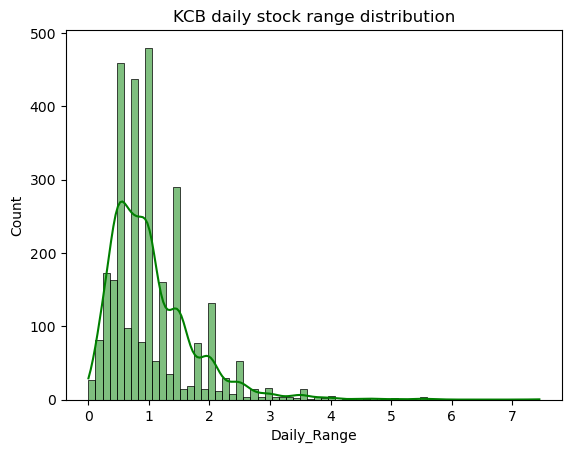

In [34]:
#lets seee the distributin of the stock daily range for KCB
sns.histplot(kcb['Daily_Range'], kde=True,color='green')
plt.title("KCB daily stock range distribution")

In [35]:
# we check for null values
kcb.isnull().sum()

DATE               0
CODE               0
NAME               0
12m Low            0
12m High           0
Day Low            0
Day High           0
Day Price          0
Previous           0
Change             0
Change%            0
Volume             0
Volume_log         0
MA_5               0
STD_5              1
MA_12              0
STD_12             1
MA_50              0
STD_50             1
MA_200             0
STD_200            1
MA_5_vs_MA_50      0
MA_12_vs_MA_200    0
HighVol_5_vs_50    0
Daily_Range        0
dtype: int64

In [37]:
# we opt to drop the first row, that has the nulls
kcb=kcb.dropna().reset_index(drop=True)

In [38]:
# we check for duplicates
kcb.duplicated().sum()

np.int64(0)

In [39]:
kcb.head(2)

,DATE,CODE,NAME,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,...,MA_12,STD_12,MA_50,STD_50,MA_200,STD_200,MA_5_vs_MA_50,MA_12_vs_MA_200,HighVol_5_vs_50,Daily_Range
0,2013-01-03,KCB,KCB Group Plc,33.75,55.5,30.25,31.5,31.0,30.25,0.05,...,30.625,0.530330,30.625,0.530330,30.625,0.530330,0,0,0,1.25
1,2013-01-04,KCB,KCB Group Plc,33.75,55.5,31.00,31.5,31.0,31.00,0.10,...,30.750,0.433013,30.750,0.433013,30.750,0.433013,0,0,0,0.50


In [41]:
kcb.isnull().sum()

DATE               0
CODE               0
NAME               0
12m Low            0
12m High           0
Day Low            0
Day High           0
Day Price          0
Previous           0
Change             0
Change%            0
Volume             0
Volume_log         0
MA_5               0
STD_5              0
MA_12              0
STD_12             0
MA_50              0
STD_50             0
MA_200             0
STD_200            0
MA_5_vs_MA_50      0
MA_12_vs_MA_200    0
HighVol_5_vs_50    0
Daily_Range        0
dtype: int64

In [71]:
# Convert DATE column to datetime
kcb['DATE'] = pd.to_datetime(kcb['DATE'], errors='coerce')

In [72]:
kcb.info()

<class 'pandas.DataFrame'>
RangeIndex: 2979 entries, 0 to 2978
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   DATE             2979 non-null   datetime64[us]
 1   CODE             2979 non-null   str           
 2   NAME             2979 non-null   str           
 3   12m Low          2979 non-null   float64       
 4   12m High         2979 non-null   float64       
 5   Day Low          2979 non-null   float64       
 6   Day High         2979 non-null   float64       
 7   Day Price        2979 non-null   float64       
 8   Previous         2979 non-null   float64       
 9   Change           2979 non-null   float64       
 10  Change%          2979 non-null   float64       
 11  Volume           2979 non-null   float64       
 12  Volume_log       2979 non-null   float64       
 13  MA_5             2979 non-null   float64       
 14  STD_5            2979 non-null   float64       
 15

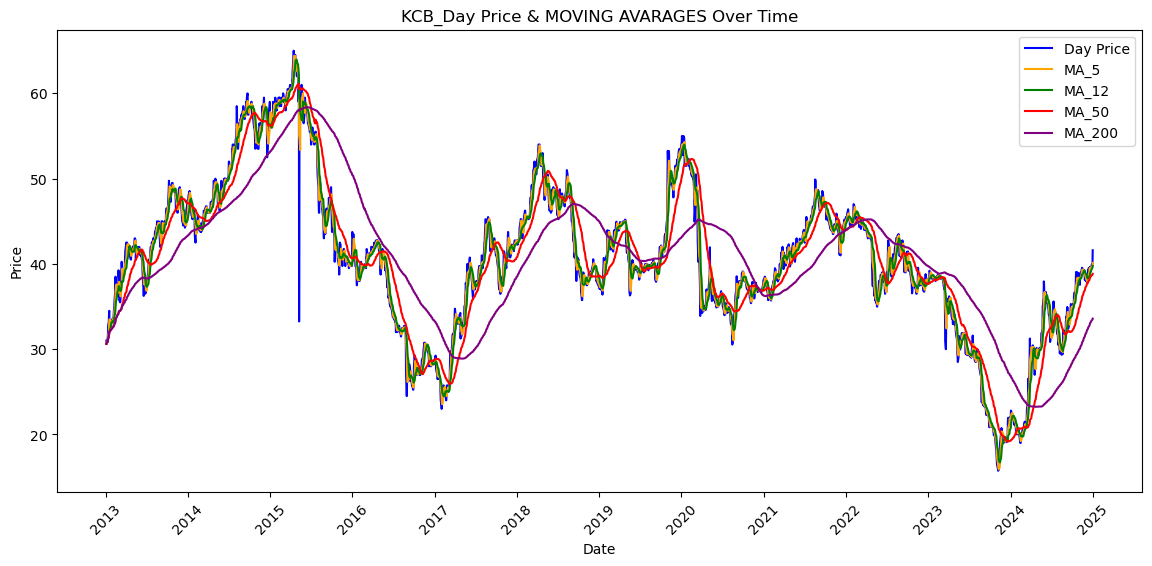

In [73]:
#LETS SEE THE TRENDS OF THE DAILY PRICE VS THE MOVING AVERAGES
import matplotlib.dates as mdates

plt.figure(figsize=(14,6))
plt.plot(kcb['DATE'], kcb['Day Price'], label='Day Price', color='blue')
plt.plot(kcb['DATE'], kcb['MA_5'], label='MA_5', color='orange')
plt.plot(kcb['DATE'], kcb['MA_12'], label='MA_12', color='green')
plt.plot(kcb['DATE'], kcb['MA_50'], label='MA_50', color='red')
plt.plot(kcb['DATE'], kcb['MA_200'], label='MA_200', color='purple')
plt.title('KCB_Day Price & MOVING AVARAGES Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.YearLocator())   # one tick per year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()


## KCB Moving Averages Insights

### 1. Cyclical Trends
**Observation:** KCB cycles above/below **MA_200** every 1.5–2 years.  
**Implication:** Shows **mean-reverting behavior**, with regular trend reversals rather than long-term directional trends.

### 2. Current Bullish Momentum
**Observation:** Short-term MAs (5, 12, 50) have crossed **above MA_200** (late 2024–2025).  
**Implication:** A **Golden Cross** indicates a bullish trend; MA_200 acts as a **support floor**.

### 3. Frequent False Breaks
**Observation:** Price often crosses MA_50/MA_200 then reverses (e.g., 2018, 2021).  
**Implication:** High **whipsaw risk**; stop-losses based solely on MAs may trigger prematurely.

### 4. Flash Recoveries
**Observation:** V-shaped recovery in early 2024.  
**Implication:** KCB can rebound quickly, creating **rapid entry opportunities** but also risk of missing reversals.

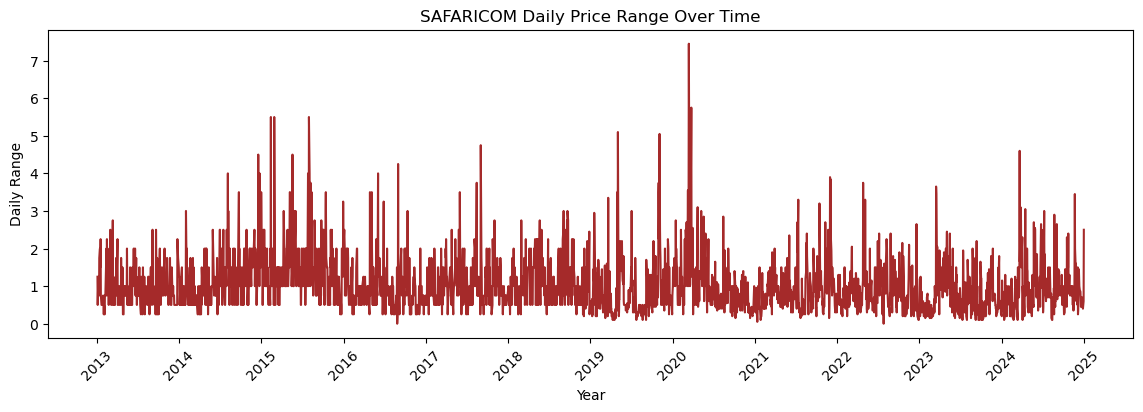

In [74]:
#LETS SEE THE DAILY RANGE OVER TIME
import matplotlib.dates as mdates

plt.figure(figsize=(14,4))
plt.plot(kcb['DATE'], kcb['Daily_Range'], color='brown')
plt.title('SAFARICOM Daily Price Range Over Time')
plt.xlabel('Year')
plt.ylabel('Daily Range')

# Set major ticks to yearly intervals
plt.gca().xaxis.set_major_locator(mdates.YearLocator())  # one tick per year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.show()

## KCB Daily Range Time-Series Insights

### 1. Extreme Shock Susceptibility
**Observation:** Daily ranges have spiked to **5–7.5 KES**, surpassing Safaricom’s ~3.5 KES peak.  
**Implication:** KCB exhibits **high tail-risk**, requiring stress tests for extreme single-day moves.

### 2. Volatility Regime Shifts
**Observation:** Baseline volatility was higher and noisier between 2013–2017 than in 2023–2024.  
**Implication:** KCB undergoes **regime changes**; even in calmer periods, sudden spikes remain possible.

### 3. Frequent Mid-Level Spikes
**Observation:** Regular spikes occur around **3–4 KES** annually.  
**Implication:** These are **normal high-volatility days**, not anomalies; risk buffers should account for them.

### 4. Rapid Mean Reversion
**Observation:** After major spikes, daily ranges often revert quickly to ~1.0 KES.  
**Implication:** Volatility shocks are usually **short-lived**, reflecting one-day events rather than extended clusters.

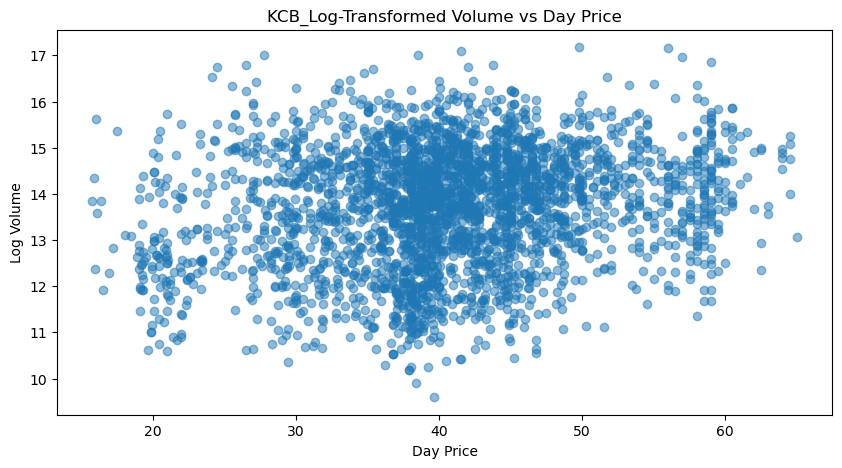

In [75]:
#LETS SEE THE VOLUME VS PRICE RELATIONS
plt.figure(figsize=(10,5))
plt.scatter(kcb['Day Price'], kcb['Volume_log'], alpha=0.5)
plt.title('KCB_Log-Transformed Volume vs Day Price')
plt.xlabel('Day Price')
plt.ylabel('Log Volume')
plt.show()

## KCB Volume vs. Price Insights

### 1. Positive Price–Volume Correlation
**Observation:** Scatter shows a slight **upward tilt**.  
**Implication:** Volume **increases with price**, supporting bullish moves; downside may see **liquidity thinning**.

### 2. High-Liquidity Anchor
**Observation:** Dense vertical cluster around **38–42 KES**.  
**Implication:** This range offers **stable liquidity**; trading outside it introduces execution uncertainty.

### 3. Greater Log-Volume Variance
**Observation:** Vertical spread ranges from **<10 to 17+**.  
**Implication:** Daily liquidity is **more erratic**, increasing **slippage risk** on large trades.

### 4. Thin Price Extremes
**Observation:** Sparse points at **<20 KES** and **>60 KES**.  
**Implication:** Significant **liquidity risk** at extremes; large rallies or crashes can cause **gapping**.

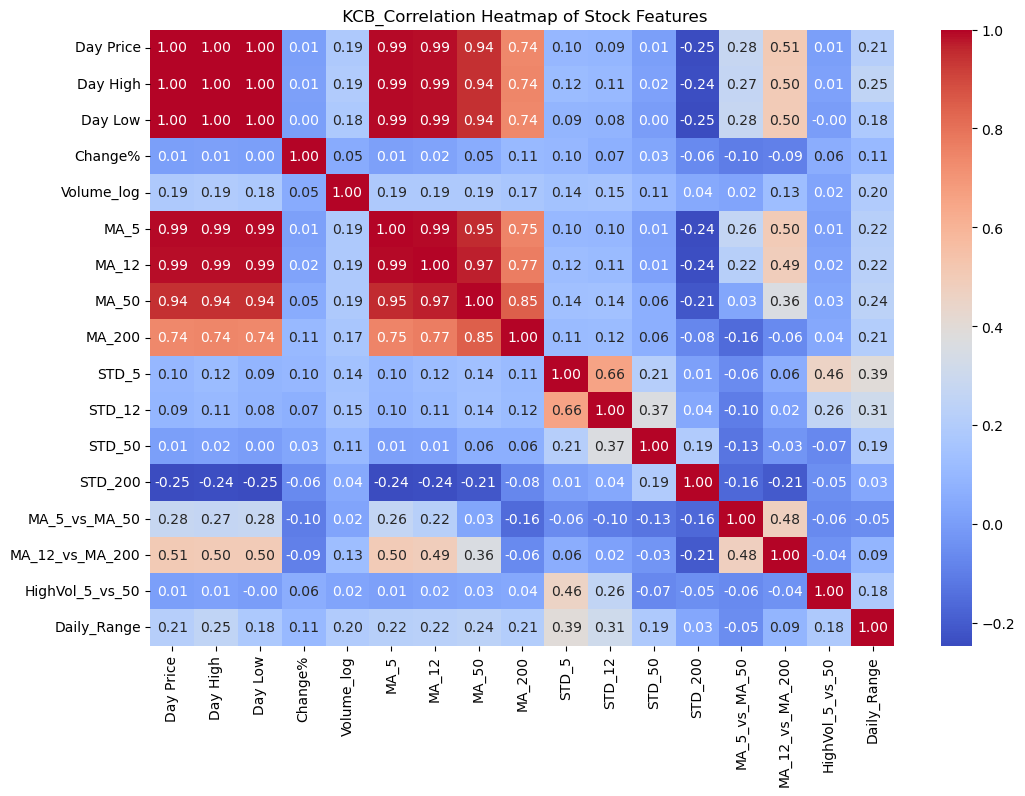

In [76]:
#LETS SEE THE CORELLATION OF OUR ENGINEERED FEATURES
features = ['Day Price','Day High','Day Low','Change%','Volume_log',
            'MA_5','MA_12','MA_50','MA_200','STD_5','STD_12','STD_50','STD_200',
            'MA_5_vs_MA_50','MA_12_vs_MA_200','HighVol_5_vs_50','Daily_Range']

plt.figure(figsize=(12,8))
sns.heatmap(kcb[features].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title(" KCB_Correlation Heatmap of Stock Features")
plt.show()

## KCB Expanded Correlation Heatmap Insights

### 1. Multicollinearity & Feature Selection
**Observation:** Core price features and short-term MAs (MA_5, MA_12) correlate **0.99–1.00**.  
**Implication:** Highly **redundant variables**; keep only Day Price and MA_200 for risk models.

### 2. Price–Volatility Inverse Relationship
**Observation:** Negative correlation (**-0.25**) between Day Price and STD_200.  
**Implication:** Lower prices coincide with **higher long-term volatility**, increasing risk during downturns.

### 3. Volatility Persistence
**Observation:** Daily_Range correlates with short-term volatility (**STD_5: 0.39, STD_12: 0.31**).  
**Implication:** High intraday ranges signal **continued turbulence** over the next 5–12 days.

### 4. Momentum Confirmation
**Observation:** MA_12_vs_MA_200 spread correlates **0.51** with Day Price.  
**Implication:** Strong **trend-following signal**; short-term deviations from MA_200 reflect price direction.

### 5. Volume–Volatility Link
**Observation:** Volume_log correlates **0.20** with Daily_Range.  
**Implication:** High-volume days usually coincide with **high intraday volatility**, indicating aggressive moves.

## 🏗 DATA PREPARATION FOR MODELLING

In [77]:
scom.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Volume_log',
       'MA_5', 'STD_5', 'MA_12', 'STD_12', 'MA_50', 'STD_50', 'MA_200',
       'STD_200', 'MA_5_vs_MA_50', 'MA_12_vs_MA_200', 'HighVol_5_vs_50',
       'Daily_Range'],
      dtype='str')

In [78]:
kcb.columns

Index(['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High',
       'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Volume_log',
       'MA_5', 'STD_5', 'MA_12', 'STD_12', 'MA_50', 'STD_50', 'MA_200',
       'STD_200', 'MA_5_vs_MA_50', 'MA_12_vs_MA_200', 'HighVol_5_vs_50',
       'Daily_Range'],
      dtype='str')

In [81]:
# we opt keep the features that havve signal importance
features = ['Day Price','12m Low','12m High','Day Low','Day High','Previous',
            'Volume_log','MA_5','STD_5','MA_12','STD_12','MA_50','STD_50',
            'MA_200','STD_200','MA_5_vs_MA_50','MA_12_vs_MA_200','HighVol_5_vs_50',
            'Daily_Range']

# Save Safaricom dataset
scom_model = scom[features]
scom_model.to_csv(r"C:\Users\Win\NSE Project\Data\2013 to 2024 cosolidated_SAFARICOM_MODELLING_data.csv", index=False)

# Save KCB dataset
kcb_model = kcb[features]
kcb_model.to_csv(r"C:\Users\Win\NSE Project\Data\2013 to 2024 cosolidated_KCB_MODELLING_data.csv", index=False)

## ☺ ends exploratory data aanlysis phase